In [40]:
import yfinance as yf
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import math
from arch import arch_model
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [50]:
# 1. Data Acquisition and Preprocessing
ticker = "SPY"
data = yf.download(ticker, start="2008-01-01")
data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

# Target: 20-day rolling volatility
data["volatility"] = data["log_return"].rolling(20).std()
data = data.dropna()

window = 60
features_raw = data[["log_return", "volatility", "Volume"]].values
target_raw = data["volatility"].values

# GARCH works best with percentage returns
returns = data["log_return"] * 100

/tmp/ipykernel_611/720368863.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2008-01-01")
[*********************100%***********************]  1 of 1 completed


In [42]:
# Time-series split (80% train, 20% test)
split_idx = int(len(data) * 0.8)

# Fit scaler ONLY on training data
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(features_raw[:split_idx])
test_features_scaled = scaler.transform(features_raw[split_idx:])
features_scaled = np.vstack((train_features_scaled, test_features_scaled))

X, y = [], []
for i in range(window, len(features_scaled)):
    X.append(features_scaled[i-window:i])
    y.append(target_raw[i])

X, y = np.array(X), np.array(y)
split = split_idx - window

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
test_dates = data.index[window:][split:]

In [43]:
# 2. Transformer Model Architecture
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class VolatilityTransformer(nn.Module):
    def __init__(self, feature_size=3, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_layer = nn.Linear(feature_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
        self.softplus = nn.Softplus()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x[:, -1, :] # Use only the last day's output for prediction
        return self.softplus(self.fc(x)).squeeze()

In [44]:
# 3. Training Loop
model = VolatilityTransformer()
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

model.train()
for epoch in range(20):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

In [45]:
# 4. GARCH Baseline
# Fit GARCH on training data
train_returns = returns.iloc[:split_idx]
garch_spec = arch_model(train_returns, vol='Garch', p=1, q=1)
garch_res = garch_spec.fit(disp="off")

# Apply the trained GARCH parameters to the FULL dataset to get test forecasts
full_garch_spec = arch_model(returns, vol='Garch', p=1, q=1)
fixed_res = full_garch_spec.fix(garch_res.params)

# Rescale GARCH output: divide by 100 to match the 'Actual Volatility' decimal scale
garch_vol_all = fixed_res.conditional_volatility / 100
garch_vol_test = garch_vol_all.iloc[split_idx:]

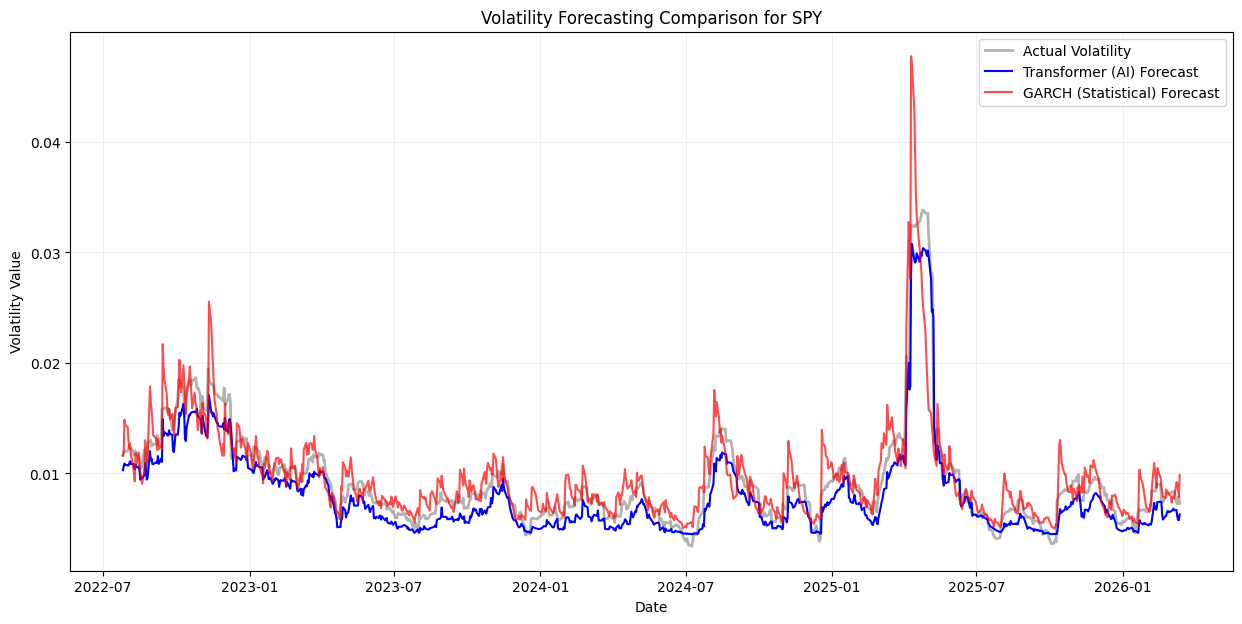

In [51]:
# 5. Final Evaluation and Visualization
model.eval()
with torch.no_grad():
    transformer_preds = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

plt.figure(figsize=(15, 7))

plt.plot(test_dates, y_test, label="Actual Volatility", color='black', alpha=0.3, lw=2)
plt.plot(test_dates, transformer_preds, label="Transformer (AI) Forecast", color='blue', lw=1.5)
plt.plot(test_dates, garch_vol_test.values, label="GARCH (Statistical) Forecast", color='red', alpha=0.7, lw=1.5)

plt.title(f"Volatility Forecasting Comparison for {ticker}")
plt.xlabel("Date")
plt.ylabel("Volatility Value")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

As visible from the volatility curves the GARCH predictions are way more higher than actual whereas Transformer is always lesser than actual vol.

In [47]:
# 6. Performance Metrics
from sklearn.metrics import mean_squared_error
print(f"Transformer RMSE: {np.sqrt(mean_squared_error(y_test, transformer_preds)):.6f}")
print(f"GARCH RMSE: {np.sqrt(mean_squared_error(y_test, garch_vol_test.values)):.6f}")

Transformer RMSE: 0.001630
GARCH RMSE: 0.002308


Creating a consolidated prediction of Volatility using scipy optimize

In [48]:
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Ensure both models are in the same units (decimal vs percentage)
trans_vals = np.array(transformer_preds).flatten()
garch_vals = np.array(garch_vol_test.values).flatten()
actual_vals = np.array(y_test).flatten()

print(f"Mean Actual:      {actual_vals.mean():.6f}")
print(f"Mean Transformer: {trans_vals.mean():.6f}")
print(f"Mean GARCH:       {garch_vals.mean():.6f}")

# If GARCH is 100x bigger than Actual, fix it here:
if garch_vals.mean() > actual_vals.mean() * 10:
    print("Warning: GARCH scale mismatch detected. Adjusting GARCH...")
    garch_vals = garch_vals / 100

# --- STEP 2: ROBUST OPTIMIZATION ---
def objective(weights):
    a, b = weights
    # We are finding the best multipliers
    ensemble = a * trans_vals + b * garch_vals
    return np.mean((ensemble - actual_vals)**2)

# Try multiple starting points to avoid getting stuck at 0.5
best_res = None
for start_guess in [[0.5, 0.5], [1.0, 0.1], [0.1, 1.0]]:
    res = minimize(
        objective,
        start_guess,
        method='L-BFGS-B',
        bounds=[(0, 2), (0, 2)],
        options={'eps': 1e-3} # Larger "change value" (step size)
    )
    if best_res is None or res.fun < best_res.fun:
        best_res = res

a_opt, b_opt = best_res.x
print(f"\nSUCCESS! Optimal Multipliers Found:")
print(f"a (Transformer) = {a_opt:.4f}")
print(f"b (GARCH)       = {b_opt:.4f}")

Mean Actual:      0.009316
Mean Transformer: 0.008019
Mean GARCH:       0.009697

SUCCESS! Optimal Multipliers Found:
a (Transformer) = 1.0000
b (GARCH)       = 0.1000


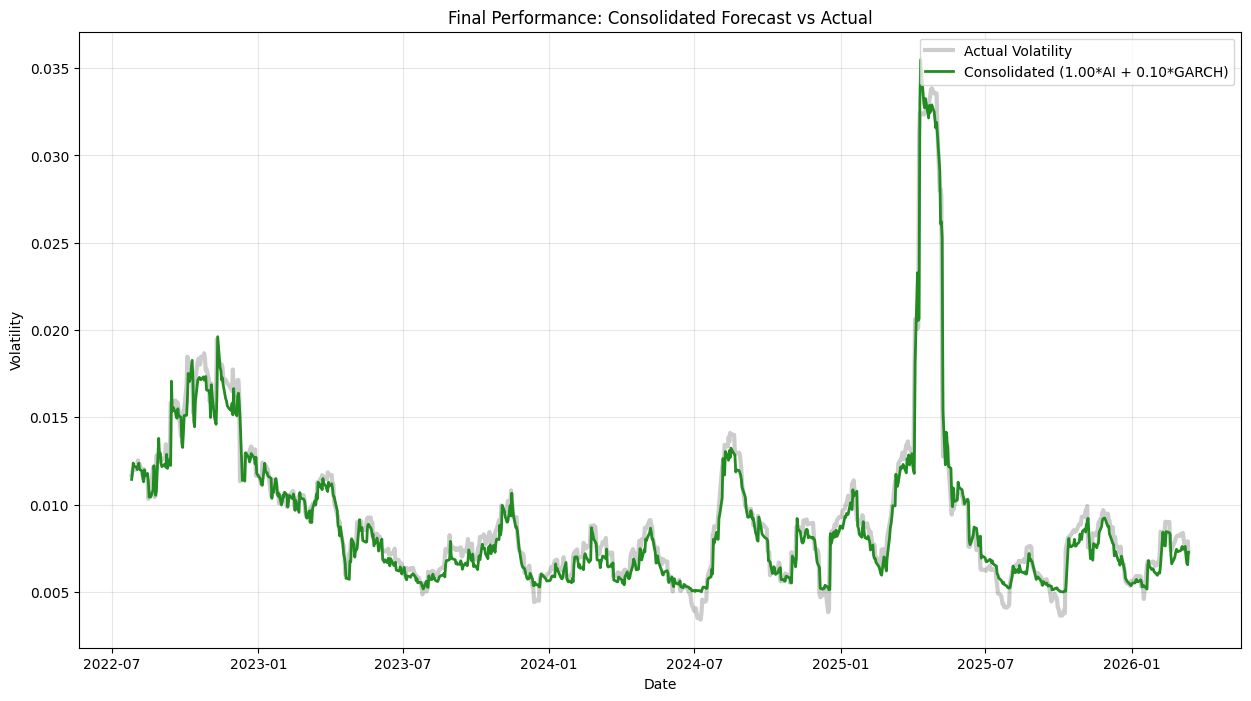


RMSE Comparison:
Transformer Only:  0.001630
GARCH Only:        0.002308
Consolidated Fit:  0.000920


In [49]:
# --- CONSOLIDATED GRAPH ---
consolidated_curve = a_opt * trans_vals + b_opt * garch_vals

plt.figure(figsize=(15, 8))

plt.plot(test_dates, actual_vals, label="Actual Volatility", color='black', alpha=0.2, lw=3)

plt.plot(test_dates, consolidated_curve, label=f"Consolidated ({a_opt:.2f}*AI + {b_opt:.2f}*GARCH)",
         color='forestgreen', lw=2)

# plt.plot(test_dates, trans_vals, label="Transformer (Raw AI)", color='blue', alpha=0.4, linestyle='--')
# plt.plot(test_dates, garch_vals, label="GARCH (Raw Stats)", color='red', alpha=0.4, linestyle='--')

plt.title("Final Performance: Consolidated Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Final Improvement Report
print(f"\nRMSE Comparison:")
print(f"Transformer Only:  {np.sqrt(mean_squared_error(actual_vals, trans_vals)):.6f}")
print(f"GARCH Only:        {np.sqrt(mean_squared_error(actual_vals, garch_vals)):.6f}")
print(f"Consolidated Fit:  {np.sqrt(mean_squared_error(actual_vals, consolidated_curve)):.6f}")

We can see that there is a significant reduction in RMSE when we use consolidated volatility prediction